In [1]:
# Load Data
import numpy as np

container = np.load('split_data.npz')

# Access data
X_train = container['X_train']
y_train = container['y_train']

# Access data
X_test = container['X_test']
y_test = container['y_test']

In [5]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score
from tqdm import tqdm

result_list = []

alpha_list = [1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1, 1e+1]

poly_ker_params_list = [0, 0.5, 1.0, 2.0]
gaussian_ker_params_list = [1e-2, 1e-1, 1.0, 1e+1]
laplacian_ker_params_list = [1e-2, 1e-1, 1.0, 1e+1]
sigmoid_ker_params_list = [(alpha, c) 
                           for alpha in [1e-3, 1e-2, 1e-1, 1]
                           for c in [-1, 0, 1]]

# Calculate total iterations for progress bar
total_iterations = (len(alpha_list) *  # linear kernel
                   len(alpha_list) * len(gaussian_ker_params_list) +  # gaussian
                   len(alpha_list) * len(poly_ker_params_list) +  # poly2
                   len(alpha_list) * len(poly_ker_params_list) +  # poly3
                   len(alpha_list) * len(laplacian_ker_params_list) +  # laplacian
                   len(alpha_list) * len(sigmoid_ker_params_list))  # sigmoid

# Create progress bar
with tqdm(total=total_iterations, desc="Training models") as pbar:
    for alpha in alpha_list:
        # Linear kernel
        model = KernelRidge(kernel='linear', alpha=alpha)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_train)
        score = r2_score(y_train, y_pred)
        
        params = {'alpha': alpha, 'kernel': 'linear'}
        result = {'score': score, 'params': params}
        result_list.append(result)
        pbar.update(1)
        
        # Gaussian/RBF kernel
        for gaussian_ker_param in gaussian_ker_params_list:
            gamma = gaussian_ker_param
            model = KernelRidge(kernel='rbf', gamma=gamma, alpha=alpha)
            model.fit(X_train, y_train)
        
            y_pred = model.predict(X_train)
            score = r2_score(y_train, y_pred)
        
            params = {'alpha': alpha, 'kernel': 'gaussian', 'gamma': gamma} 
            result = {'score': score, 'params': params}
            result_list.append(result)
            pbar.update(1)

        # Polynomial kernel (degree 2)
        for poly_ker_params in poly_ker_params_list:
            coef0 = poly_ker_params
            model = KernelRidge(kernel='poly', degree=2, coef0=coef0, alpha=alpha)
            model.fit(X_train, y_train)
        
            y_pred = model.predict(X_train)
            score = r2_score(y_train, y_pred)
        
            params = {'alpha': alpha, 'kernel': 'poly2', 'coef0': coef0} 
            result = {'score': score, 'params': params}
            result_list.append(result)
            pbar.update(1)

        # Polynomial kernel (degree 3)
        for poly_ker_params in poly_ker_params_list:
            coef0 = poly_ker_params
            model = KernelRidge(kernel='poly', degree=3, coef0=coef0, alpha=alpha)
            model.fit(X_train, y_train)
        
            y_pred = model.predict(X_train)
            score = r2_score(y_train, y_pred)
        
            params = {'alpha': alpha, 'kernel': 'poly3', 'coef0': coef0} 
            result = {'score': score, 'params': params}
            result_list.append(result)
            pbar.update(1)

        # Laplacian kernel
        for laplacian_ker_params in laplacian_ker_params_list:
            gamma = laplacian_ker_params
            model = KernelRidge(kernel='laplacian', gamma=gamma, alpha=alpha)
            model.fit(X_train, y_train)
        
            y_pred = model.predict(X_train)
            score = r2_score(y_train, y_pred)
        
            params = {'alpha': alpha, 'kernel': 'laplacian', 'gamma': gamma} 
            result = {'score': score, 'params': params}
            result_list.append(result)
            pbar.update(1)   

        # Sigmoid kernel (fixed the kernel name in params)
        for sigmoid_ker_params in sigmoid_ker_params_list:
            coef0, gamma = sigmoid_ker_params
            model = KernelRidge(kernel='sigmoid', coef0=coef0, gamma=gamma, alpha=alpha)
            model.fit(X_train, y_train)
        
            y_pred = model.predict(X_train)
            score = r2_score(y_train, y_pred)
        
            params = {'alpha': alpha, 'kernel': 'sigmoid', 'coef0': coef0, 'gamma': gamma} 
            result = {'score': score, 'params': params}
            result_list.append(result)
            pbar.update(1)

best_result = max(result_list, key=lambda x: x['score'])

print(f"Max Score: {best_result['score']}")
print(f"Best Params: {best_result['params']}")

# result_list.sort(key=lambda x: x['score'], reverse=True)
# result_list

Training models:   2%|█▉                                                                                                 | 9/448 [00:19<14:21,  1.96s/it]/home/abner-study/Desktop/Doutorado/Subjects/Teoria do Aprendizado Estatístico/Atividade 2/INFO7070-StatisticalLearningTheory-asgmt1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
Training models:   2%|█▉                                                                                               | 9/448 [01:54<1:32:47, 12.68s/it]


KeyboardInterrupt: 

In [2]:
from sklearn.kernel_ridge import KernelRidge

model = KernelRidge(kernel='laplacian', gamma=1, alpha=1e-3)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.9151052172498075


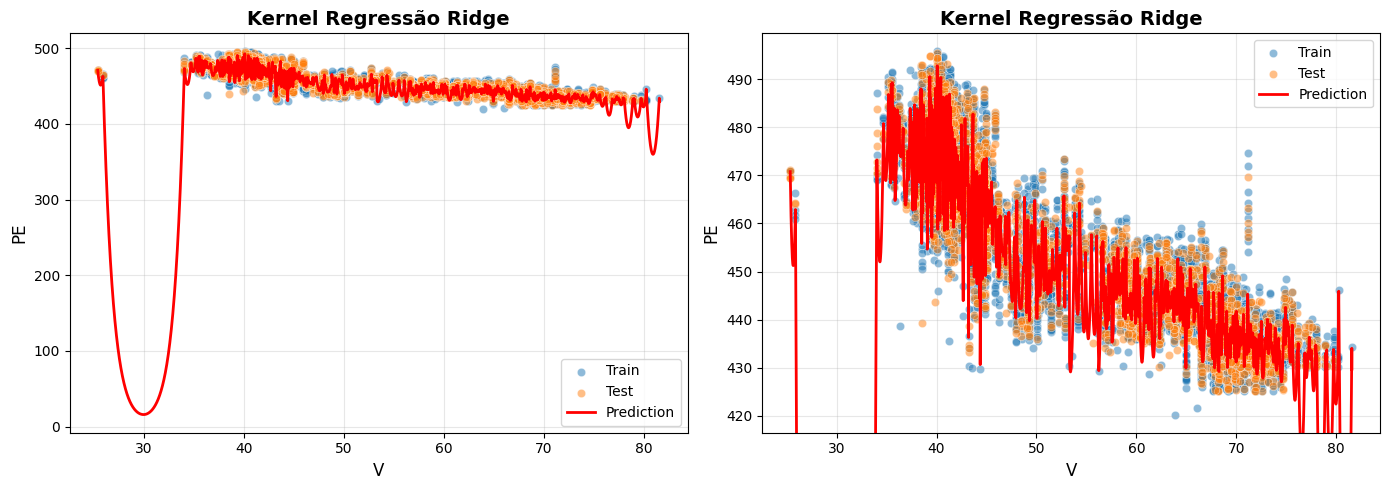

In [4]:
from utils import plot_predictions, plot_predictions_trunc

step = 0.01
X_min = min(X_train.min(), X_test.min())
X_max = max(X_train.max(), X_test.max())
X_line = np.arange(X_min, X_max + step, step).reshape(-1, 1)
y_line = model.predict(X_line)

plot_predictions_trunc(X_line, y_line, X_train, y_train, X_test, y_test, title='Kernel Regressão Ridge', name='Images/kernel_ridge_regression.png')